## NTU Paper Documentation

**Introduction**

This paper, "Generative Agent-Based Modelling in Evacuation Simulation" (2025), explores how to make crowd simulations more realistic by injecting human personality & psychology into a traditional evacuation model.

In this paper, the Social Force Model is used. This Model treats people as "rational agents", i.e. simple particles in a given space. However, the nuances of human behaviour under stress such as panic, impatience, emotions, adrenaline and desire to stay with a group can lead to inaccurate safety planning.

Hence, this project integrates Large Language Models (Llama 3) with Agent-Based Modelling (ABM) to simulate how human personality traits (The Big Five in particular) influence crowd evacuation dynamics.

In [1]:
# install necessary libraries if not present
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pysocialforce', 'groq', 'numpy', 'matplotlib', 'pandas', 'seaborn'])


0

We use PySocialForce for the physics and Groq for the AI processing.

PySocialForce: a pure Python library that simulates crowd dynamics, movement and social interactions. Each individual is an entity that reacts to external forces and constraints.

Groq: official library for accessing the Groq REST API, enabling the running of LLMs (Large Language Models) with extremely low latency.

In [2]:
# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import groq
import seaborn as sns

Before progressing further, cite & locate the cloned repository such that we can extract the code for later

In [3]:
import sys, os, importlib
from pathlib import Path

def find_repo_path(repo_name='FYP-Generative-Agent-Evacuation-Simulation'):
    start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        candidate = p / repo_name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find '{repo_name}' from: {start}")

# add the cloned repo folder to Python path (robust to notebook folder moves)
repo_path = find_repo_path()
if str(repo_path) not in sys.path:
    sys.path.insert(0, str(repo_path))

# this is to fix an earlier bug
# the notebook importing the pip installed pysocialforce
# not the cloned repo version
import pysocialforce as psf
importlib.reload(psf)

print('Using pysocialforce from:', psf.__file__)
print(f'Successfully linked to: {repo_path}')


Using pysocialforce from: C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation\pysocialforce\__init__.py
Successfully linked to: C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation


In [4]:
# import the evacuation classes if necessary - if the simulation doesn't run
# otherwise, comment it out
# from pysocialforce.sceneforevacuation import PedStateEvacuation, EnvStateEvacuation

**Mathematical Foundation**

The simulation relies on the Social Force Model, where the total force $F_i$ acting on an agent $i$ is defined as:

$$F_{i} = F_{i}^{desire} + \sum_{j \neq i} F_{ij}^{social} + \sum_{w} F_{iw}^{obstacle}$$

*   **Desire Force:** The agent's internal drive to reach the exit.
*   **Social Force:** Repulsive forces from other agents to maintain personal space.
*   **Obstacle Force:** Interaction with walls or barriers.

In [5]:
# how the Math translates into Pythom
# these constraints define the Strength of the abovementioned forces

physics_params = {
    "v_desired_default": 1.3,  # standard walking speed (m/s)
    "v_desired_impatient": 1.8,  # speed for high-neuroticism agents
    "relaxation_time": 0.5,  # time taken to reach desires speed (tau)
    "social_repulsion": 2.0,  # strength of the F_ij force
    "obstacle_repulsion": 10.0  # strength of the F_iw force
}

print("physics parameters initialized based on Social Force Model (SFM) Theory.")

physics parameters initialized based on Social Force Model (SFM) Theory.


**Behavioural Grid**

Traditional Agent-Based Models (ABM) assign fixed, "robotic" parameters to agents. To create a more realistic simulation, we use Meta's Llama 3 to act as a "psychological engine". By providing the AI with a persona based on the Big Five Personality Traits (Openness, Conscientiousness, Extraversion, Agreeableness, Neuroticism), the AI predicts how a human would actually behave in a high-stress evacuation scenario.

**take a deeper dive on how they do modelling

- how does it affect/connect?
- how do the 2 concepts of SFM & Behavioural Grid come together?
- exact prompts use... why said speed? why is the speed change?
- how would I recreate this study?
- what affects what we're attracted to or repel?
- would I take this approach? Pros & Cons


**Challenge: API Latency**

Running a LLM for every single agent at every timestep of a simulation is computationally expensive and slow. In real-time crowds of large numbers (say > 50 agents), the simulation lags significantly waiting for API responses.


**Solution: Behavioural Grid**

To solve the problem, the author implemented a Pre-Computed Behavioural Grid:

1. Prompt Engineering - the author prompted Llama 3 with various combinations of personality scores & environmental conditions (e.g. Highly neurotic, Crowded Exit. What is your desired walking speed?)
2. Data Mapping - AI's qualitative responses converted into quantitative parameters, like Desired Velocity ($v_d$) and Patience Thresholds.
3. Lookup Table - during the simulation, the agents simply lookup their behaviour from the grid based on assigned personality, eliminating the need for live AI calls; drasically saving API costs & processing time.

**Key Personality Drivers**

Based on the research, two traits had the most significant impact on the simulation outcomes:

1. Neuroticism: Linked to "Impatient" behavior, leading to higher speeds but potential "clogging" at exits.  
2. Agreeableness: Linked to "Social" behavior, where agents prioritize staying with a group, affecting the overall flow and cohesion of the crowd.

**how do they use this to model? is this a validated type of model that everyone uses?

In [6]:
import json
from pathlib import Path

def find_repo_path(repo_name='FYP-Generative-Agent-Evacuation-Simulation'):
    start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        candidate = p / repo_name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find '{repo_name}' from: {start}")

repo_root = find_repo_path()
file_path = repo_root / 'behavior grid analysis' / 'behavior impatience analysis' / 'behavior_grid.json'

if not file_path.exists():
    raise FileNotFoundError(f'Could not find behavior_grid.json at: {file_path}')

with open(file_path, 'r', encoding='utf-8') as f:
    behavior_data = json.load(f)

# Convert to dataframe for easy search/filter
grid_df = pd.DataFrame(behavior_data)

# Helper function to simulate how an agent 'thinks' using the grid
def get_agent_behavior(traits, fullness, distance):
    match = grid_df[
        (grid_df['traits'].apply(lambda x: x['Neuroticism'] == traits['Neuroticism'])) &
        (grid_df['condition'].apply(lambda x: x['fullness'] == fullness)) &
        (grid_df['condition'].apply(lambda x: x['distance_to_exit'] == distance))
    ]

    if not match.empty:
        return match.iloc[0]['state_of_impatience']
    return 'No'

# Test case: High Neuroticism agent in a 67% full room, near the exit
sample_traits = {'Neuroticism': 'High'}
impatience_status = get_agent_behavior(sample_traits, '67%', 'Near')

print(f'Llama 3 Predicted Impatience: {impatience_status}')
print('-' * 30)
print('Preview of the Behavioural Grid:')
display(grid_df[['age_category', 'state_of_impatience']].head(10))


Llama 3 Predicted Impatience: Yes
------------------------------
Preview of the Behavioural Grid:


,age_category,state_of_impatience
0,Young Adult,Yes
1,Young Adult,Yes
2,Young Adult,Yes
3,Young Adult,Yes
4,Young Adult,Yes
5,Young Adult,Yes
6,Young Adult,Yes
7,Young Adult,Yes
8,Young Adult,No
9,Young Adult,Yes


**Running the Simulation**

In this section, we initialise and run the evacuation simulation using the Social Force Framework.

We start by defining the environment - a 20m x 20m room with 1 exit door on the right wall. The wall is split into 2 obstacle segments to create the door opening.

In [7]:
#initialise the square room & deploy the seed
np.random.seed(42)

def create_square_room_w_exit(size=20.0, door_width=1.2):
    door_half = door_width / 2

    return [
        [-size/2, size/2, -size/2, -size/2],      # bottom
        [-size/2, size/2,  size/2,  size/2],      # top
        [-size/2, -size/2, -size/2, size/2],      # left
        [ size/2,  size/2, -size/2, -door_half],  # right-bottom
        [ size/2,  size/2,  door_half, size/2],   # right-top
    ]

Create agents - generate initial agent positions randomly inside the room:

* **Position (px, py)**
* **Velocity (vx, vy)** - directed towards the exit
* **Goal (gx, gy)** - beyond the door

In [8]:
def generate_random_positions(n_agents, room_size=20.0, margin=2.0):
    return np.random.uniform(
        low = -(room_size / 2) + margin,
        high = (room_size / 2) - margin,
        size = (n_agents, 2),
    )

Add behavioural characteristics (for behavioural model):

For each agent, we assign demographic/personality fields that match the behaviour grid schema:

- Age category; Gender; Big 5 Trait level (Low/High)

In [9]:
def generate_characteristics(n_agents):
    age_categories = ['Young Adult', 'Adult', 'Middle Age']
    genders = ['male', 'female']
    trait_levels = ['Low', 'High']
    chars = []

    # loop through the agents, and assign each one as a unique person
    for _ in range(n_agents):
        age = np.random.choice(age_categories)
        gender = np.random.choice(genders)
        traits = [np.random.choice(trait_levels) for _ in range(5)]  # O, C, E, A, N
        chars.append([age, gender] + traits)
    return chars

For the below code, we build a function which initialises simulator variants, runs the simulation and records outputs for analysis.

1. Initialise Simulator Variants
- Baseline model: physics based evacuation without behavioural impatience
- Behavioural model: evacuation with behaviour-grid-driven impatience dynamics

2. Run time-stepped simulation
- The simulation advances in **discrete steps**, until all agents escape, OR a max step limit is reached (safety stop)

3. Record outputs for analysis
- During execution, we store cumulative escaped agents over time, as well as per-agent trajectory coordinates.

In [10]:
def run_simulation(n_agents=50, behavioral=True, max_steps=3000, tau=0.5):
    room_size = 20.0
    door_width = 1.2
    door_center = np.array([room_size/2, 0.0])
    final_goal = door_center + np.array([3.0, 0.0])
    pos0 = generate_random_positions(n_agents, room_size)
    vel0 = np.zeros((n_agents, 2))
    for i in range(n_agents):
        d = final_goal - pos0[i]
        d = d / np.linalg.norm(d)
        vel0[i] = d * 0.5
    goals = np.tile(final_goal, (n_agents, 1))
    obstacles = create_square_room_w_exit(room_size, door_width)
    # track trajectories
    tracks = {i: [pos0[i].copy()] for i in range(n_agents)}
    escaped_counts = [0]
    times = [0.0]
    try:
        _repo = repo_path
    except NameError:
        from pathlib import Path
        def find_repo_path(repo_name='FYP-Generative-Agent-Evacuation-Simulation'):
            start = Path.cwd().resolve()
            for p in [start, *start.parents]:
                candidate = p / repo_name
                if candidate.exists():
                    return candidate
            raise FileNotFoundError(f"Could not find '{repo_name}' from: {start}")
        _repo = find_repo_path()
    exp_dir = _repo / 'experiments'
    cfg = exp_dir / "example.toml"
    behavior_json = _repo / 'behavior grid analysis' / 'behavior impatience analysis' / 'behavior_grid.json'
    if behavioral:
        init = np.empty((n_agents, 14), dtype=object)
        init[:, :2] = pos0
        init[:, 2:4] = vel0
        init[:, 4:6] = goals
        init[:, 6] = tau
        chars = generate_characteristics(n_agents)
        for i, c in enumerate(chars):
            init[i, 7:] = c
        sim = psf.SimulatorWithBehavior(
            init, groups=None, obstacles=obstacles,
            config_file=cfg, behavior_file=behavior_json
        )
    else:
        init = np.zeros((n_agents, 6), dtype=float)
        init[:, :2] = pos0
        init[:, 2:4] = vel0
        init[:, 4:6] = goals
        sim = psf.Simulator(
            init, groups=None, obstacles=obstacles,
            config_file=cfg,
            ped_state_class=psf.sceneforevacuation.PedStateEvacuation,
            env_state_class=psf.sceneforevacuation.EnvStateEvacuation
        )
    for step in range(1, max_steps + 1):
        sim.step(1)
        p = sim.peds.pos()
        for i in range(n_agents):
            tracks[i].append(p[i].copy())
        escaped = int(np.sum(sim.peds.escaped))
        escaped_counts.append(escaped)
        times.append(step * tau)
        if escaped == n_agents:
            break
    return {
        "sim": sim,
        "tracks": tracks,
        "escaped_counts": np.array(escaped_counts),
        "times": np.array(times),
        "tau": tau,
        "n_agents": n_agents
    }


In [11]:
# now that this function is up, we can run both models

base = run_simulation(n_agents=50, behavioral=False, max_steps=3000)
behv = run_simulation(n_agents=50, behavioral=True, max_steps=3000)

print("Base total evac time (s):", base["times"][-1])
print("Behavioral total evac time (s):", behv["times"][-1])

DEBUG:[byteflow.py:81             __init__() ] bytecode dump:
>          0	NOP(arg=None, lineno=97)
           2	RESUME(arg=0, lineno=97)
           4	LOAD_FAST(arg=0, lineno=101)
           6	LOAD_CONST(arg=1, lineno=101)
           8	LOAD_CONST(arg=1, lineno=101)
          10	BUILD_SLICE(arg=2, lineno=101)
          12	LOAD_CONST(arg=2, lineno=101)
          14	LOAD_CONST(arg=3, lineno=101)
          16	BUILD_SLICE(arg=2, lineno=101)
          18	BUILD_TUPLE(arg=2, lineno=101)
          20	BINARY_SUBSCR(arg=None, lineno=101)
          24	STORE_FAST(arg=1, lineno=101)
          26	LOAD_GLOBAL(arg=1, lineno=102)
          36	LOAD_ATTR(arg=2, lineno=102)
          56	LOAD_FAST(arg=1, lineno=102)
          58	GET_ITER(arg=None, lineno=102)
          60	LOAD_FAST_AND_CLEAR(arg=2, lineno=102)
          62	SWAP(arg=2, lineno=102)
          64	BUILD_LIST(arg=0, lineno=102)
          66	SWAP(arg=2, lineno=102)
>         68	FOR_ITER(arg=33, lineno=102)
          72	STORE_FAST(arg=2, lineno=102

DEBUG: time_since_last_escape = 1, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 2, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 3, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 4, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 5, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 6, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 7, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 8, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 9, boost_timeout = 50
DEBUG: any_escaped

C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation\pysocialforce\scene.py:99: RuntimeWarning: divide by zero encountered in divide
  factor = np.minimum(1.0, max_velocity / desired_speeds)


DEBUG: time_since_last_escape = 67, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: True
should_apply_boost entered
near_exit: [False  True False False False False False False False False False False
 False False False False False  True False  True False False False False
 False  True  True False False False False  True False False False False
 False False False False  True False False False False False  True  True
 False False], practically_stopped: [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True]
TIMEOUT BOOST: No escapes for 67 steps. Boosting agents: [ 1 17 19 25 26 31 40 46 47]
DEBUG: time_since_last_escape = 68, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: True
should_apply

C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation\pysocialforce\forcewithbehavior.py:96: RuntimeWarning: invalid value encountered in divide
  force_velocity_amount = np.exp(-1.0 * diff_length / B - np.square(n_prime * B * theta))
C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation\pysocialforce\forcewithbehavior.py:97: RuntimeWarning: invalid value encountered in divide
  force_angle_amount = -np.sign(theta) * np.exp(-1.0 * diff_length / B - np.square(n * B * theta))


DEBUG: time_since_last_escape = 3, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 4, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 5, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 6, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 7, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 8, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 9, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 10, boost_timeout = 50
DEBUG: any_escaped = True
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 11, boost_timeout = 50
DEBUG: any_escaped = Tru

**Why run both models?**

Running both models evaluates the impact of personality-driven impatience - 2 conditions under the same room geometry and initial setup.

With Baseline model following standard evacuation dynamics and Behavioural accounting for trait-conditioned impatience, this controlled comparison isolates the behavioural effect and supports fair interpretation of differences in evacuation speed & congestion.


**Results and Visualisation**
1. Evacuation with Visualisation
Plot each agent's trajectory from initial position to exit region

- Path plots reveal movement structure and crowding patterns
- We inspect whether the behavioural model causes stronger flow concentration near the exit
- Congestion hotspots are identified, not just final evacuation time

DEBUG:[pyplot.py:497       switch_backend() ] Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:[pyplot.py:497       switch_backend() ] Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:[font_manager.py:1471     _findfont_cached() ] findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:[font_manager.py:1483     _findfont_cached() ] findfont: score(FontEntry(fname='C:\\Users\\kylet\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:[font_manager.py:1483     _findfont_cached() ] findfont: score(FontEntry(fname='C:\\Users\\kylet\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-pa

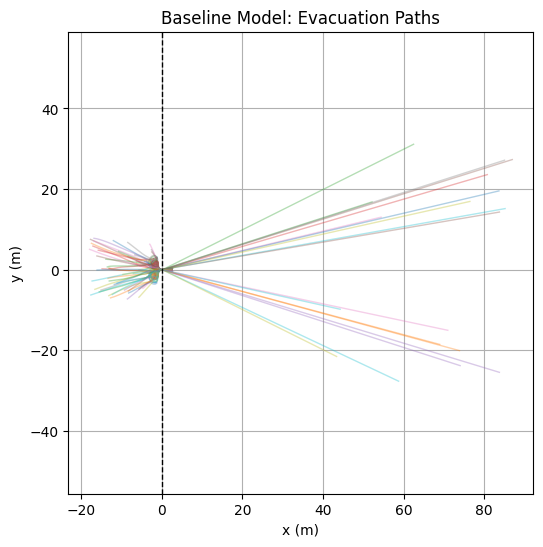

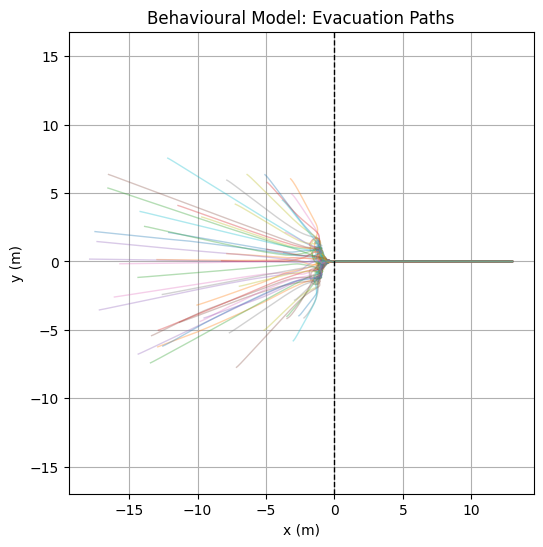

In [12]:
# create the plot
def plot_paths(result, title, room_size=20.0):
    # door is originally at +10 for a 20m room, so we  shift to make it nicer
    x_shift = room_size / 2

    plt.figure(figsize=(6, 6))
    for i, tr in result['tracks'].items():
        arr = np.array(tr)
        plt.plot(arr[:, 0] - x_shift, arr[:, 1], alpha=0.35, linewidth=1)

    plt.axvline(0, linestyle='--', linewidth=1, color='black', label='Exit Door')
    plt.title(title)
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.axis("equal")
    plt.grid(True)
    plt.show()

plot_paths(base, 'Baseline Model: Evacuation Paths')
plot_paths(behv, 'Behavioural Model: Evacuation Paths')

2. Evacuation Progress Curves
Plot cumulative escaped agents against time for both models.

- Steeper slope = faster initial evacuation
- Differences between curves show how behaviour changes system-level flow dynamics

** where is the baseline model? how has the author changed the model? is the baseline model just not including the Big 5 Traits?

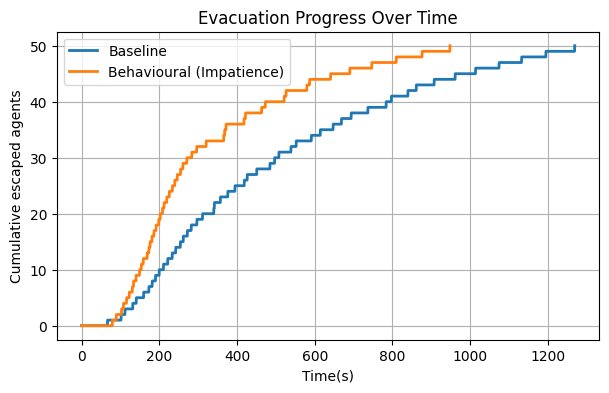

In [13]:
# Evacuation curves + initial speed comparison
plt.figure(figsize=(7, 4))
plt.plot(base['times'], base['escaped_counts'], label='Baseline', linewidth=2)
plt.plot(behv['times'], behv['escaped_counts'], label='Behavioural (Impatience)', linewidth=2)
plt.xlabel('Time(s)')
plt.ylabel('Cumulative escaped agents')
plt.title('Evacuation Progress Over Time')
plt.grid(True)
plt.legend()
plt.show()

3. Early Phase Performance Metric
To quantify 'initially faster', we compute a milestone time (e.g. T25: time till 25% of agents escape)

- Lower T25 = faster early evacuation
- Percentage difference provides a numeric speed-up estimate, making claims like 'initially X% faster' measurable & reproducible

In [14]:
# time to reach 25% evacuated
def time_to_fraction(result, frac=0.25):
    target = int(np.ceil(result['n_agents'] * frac))
    idx = np.where(result['escaped_counts'] >= target)[0]
    return result['times'][idx[0]] if len(idx) else np.nan

t25_base = time_to_fraction(base, 0.25)
t25_behv = time_to_fraction(behv, 0.25)

speedup_pct = ((t25_base - t25_behv) / t25_behv) * 100 if t25_behv > 0 else np.nan
print(f"T25 baseline: {t25_base:.2f}s, T25 behavioral: {t25_behv:.2f}s, early speed-up: {speedup_pct:.1f}%")

T25 baseline: 233.50s, T25 behavioral: 169.00s, early speed-up: 38.2%


Overall, the behavioural (impatience-aware) model shows faster early evacuation than the baseline model, consistent with the report’s main finding.  In particular, high-Neuroticism / impatient behaviour can produce a strong initial speed advantage (reported as up to **167% faster** in early phase metrics).  

However, trajectory and density patterns indicate a trade-off: the same impatience tendency increases local competition near the exit, resulting in more congestion around the doorway.  

Therefore, impatience can improve early escape rate but may reduce overall flow smoothness under bottleneck conditions.

**Final Overview - How AI is incorporated**

This project uses a hybrid modelling approach:

1. Physics layer (PySocialForce): handles movement, collision avoidance and wall interactions using the Social Force Model. (look at the documentation, how does it translate to the social force model?)
2. AI behaviour layer (LLM-Generated Behavioural Grid): Maps agent profile and crowd condition (e.g. fullness, distance to exit) to behavioural state (e.g. impatience)
3. Integration layer: during simulation, each agent's behavioural state modifies evacuation dynamics, then physics updates actual motion.

A baseline (non-behavioural) model is compared against a behavioural model to isolate the effect of AI-driven personality/impatience on evacuation outcomes.

**Conclusion**

In conclusion, this work demonstrates that combining a physics-based evacuation simulator with an AI-generated behavioural model improves realism over fixed-rule agents. The behavioural model captures heterogeneous human responses, especially impatience under stress, producing faster early evacuation in some scenarios but also increased congestion near bottlenecks. This highlights an important trade-off: behavioural urgency can improve initial throughput while harming flow stability at exits. Overall, the hybrid framework is useful for studying both evacuation speed and crowd safety dynamics.

**References**

1. Bin Ahmad, I. (2025). *Generative Agent-Based Modelling in Evacuation Simulation* (Final Year Project report, Nanyang Technological University).  
   Local file: `report/Irfaan Bin Ahmad U2121388D FYP Final Report.pdf`.

2. Bin Ahmad, I. (2025). *FYP-Generative-Agent-Evacuation-Simulation* [Source code]. GitHub.  
   URL: https://github.com/Irf2an/FYP-Generative-Agent-Evacuation-Simulation  
   Commit used: `d59725caa8a4db94a61a17cfa4ca1d11178134bc`  
   Accessed: May 8, 2026.

3. Gao, Y. (2020). *PySocialForce* [Software library]. GitHub.  
   URL: https://github.com/yuxiang-gao/PySocialForce

4. Harris, C. R., et al. (2020). Array programming with NumPy. *Nature, 585*, 357-362.  
   URL: https://doi.org/10.1038/s41586-020-2649-2

5. McKinney, W. (2010). Data structures for statistical computing in Python. In *Proceedings of the 9th Python in Science Conference* (pp. 56-61). (pandas)

6. Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90-95.

7. Groq. (2026). Groq API documentation. URL: https://console.groq.com/docs  
   Model used in this project: `llama3-70b-8192` (Meta Llama 3 via Groq API).

**Attribution and License Compliance**

This project uses and adapts open-source code from:
- https://github.com/Irf2an/FYP-Generative-Agent-Evacuation-Simulation
- https://github.com/yuxiang-gao/PySocialForce

The repository includes an MIT License (`LICENSE`), and attribution to original authors is provided in this report.  
All third-party libraries and AI services used (PySocialForce, NumPy, pandas, Matplotlib, Groq API / Llama 3) are cited above.

## Follow-up Extensions (Behavioural Grid Deep Dive)

1. **How does the behavioural grid affect/connect to modelling?**  
The behavioural grid is a lookup table that converts "agent profile + context" into a behavioral state (`state_of_impatience`: Yes/No). In simulation, this state is recalculated repeatedly and then used to alter force equations and group behavior.

2. **How do SFM and Behavioural Grid come together?**  
- SFM provides the physical motion framework: desired force, social force, and obstacle force.  
- The behavioural grid provides psychological state.  
- Integration layer: `PedStateBehavior.update_impatience_states()` sets `is_impatient` per agent, then behavior-specific force classes (`DesiredForceBehavior`, `SocialForceBehavior`, `GroupCoherenceForceBehavior`) modify the force magnitude/range and acceleration dynamics.

3. **Exact prompt and why speed changes**  
The prompt in `behavior grid generation/FullBehaviourGrid.py` asks the model to infer emergency impatience from age/gender/OCEAN traits + fullness + distance, and forces final output to `Yes` or `No`.  
In force code, speed changes are explicit design choices: impatient agents get stronger desired acceleration and higher desired speed factor. This is a modeling assumption to represent urgency/competitiveness under stress.

4. **What affects attraction/repulsion?**  
In SFM terms:
- **Attraction to goal**: desired force pushes agents toward target velocity.
- **Repulsion from people**: social force discourages collisions and personal-space violations.
- **Repulsion from walls/obstacles**: obstacle force pushes away from boundaries.
In this project, impatience alters these effects by changing interaction scale and force multipliers.


In [15]:
# Evidence pull: show where prompt and behavior-force edits are defined
from pathlib import Path
try:
    repo = repo_path
except NameError:
    def find_repo_path(repo_name='FYP-Generative-Agent-Evacuation-Simulation'):
        start = Path.cwd().resolve()
        for p in [start, *start.parents]:
            candidate = p / repo_name
            if candidate.exists():
                return candidate
        raise FileNotFoundError(f"Could not find '{repo_name}' from: {start}")
    repo = find_repo_path()
force_file = repo / 'pysocialforce' / 'forcewithbehavior.py'
prompt_file = repo / 'behavior grid generation' / 'FullBehaviourGrid.py'
force_text = force_file.read_text(encoding='utf-8')
prompt_text = prompt_file.read_text(encoding='utf-8')
keywords = [
    'impatience_speed_factor',
    'impatience_relaxation_factor',
    'gamma * 0.75',
    'force_magnitude[mask_impatient] = 1.4',
    'impatience_factors = np.where(self.peds.is_impatient[group], 0.6, 1.0)',
]
print('Behavior force edits found in forcewithbehavior.py:')
for k in keywords:
    print('-', k, '->', k in force_text)
print('\nPrompt markers in FullBehaviourGrid.py:')
for k in ['Imagine you are', 'Please provide your response in this format', 'Response - State of Impatience: [Exactly "Yes" or "No"']:
    print('-', k, '->', k in prompt_text)


Behavior force edits found in forcewithbehavior.py:
- impatience_speed_factor -> True
- impatience_relaxation_factor -> True
- gamma * 0.75 -> True
- force_magnitude[mask_impatient] = 1.4 -> True
- impatience_factors = np.where(self.peds.is_impatient[group], 0.6, 1.0) -> True

Prompt markers in FullBehaviourGrid.py:
- Imagine you are -> True
- Please provide your response in this format -> True
- Response - State of Impatience: [Exactly "Yes" or "No" -> True


**Recreate This Study (Practical Checklist)**

1. Clone the repo and install dependencies.
2. Generate behaviour grid (`behavior_grid.json`) with the same trait-condition combinations and model settings.
3. Keep room geometry, agent count, door width, and timestep constant across experiments.
4. Run baseline and behavioural models with identical random seeds/initial states.
5. Record comparable metrics: total evacuation time, early-phase rate (e.g., T25), and congestion near exits.
6. Run multiple seeds (not one run) and report mean + spread.
7. State assumptions clearly: speed multipliers and force edits are design choices, not universal truth.


**Key Personality Drivers: How Used + Validation Status**

- In this project, key drivers are identified empirically from the generated grid using Random Forest feature importance (`analysis_tools.py`), where Neuroticism and Agreeableness are highest.
- This is a **project-specific learned ranking**, not a universal constant for all populations/scenarios.
- Big Five (OCEAN) is a widely used personality framework in psychology, and evacuation research often uses trait heterogeneity, but there is no single globally validated mapping from trait values to exact evacuation force multipliers.
- Therefore: this is a defensible modeling approach, but external validation against drills/real data is still required for deployment-level claims.


**Baseline vs Behavioural Model: Direct Answers**

1. **Where is baseline model?**  
Baseline dynamics are in `pysocialforce/simulator.py` + `pysocialforce/forces.py`, and evacuation-specific logic is in `pysocialforce/sceneforevacuation.py`.

2. **How has the author changed the model?**  
Main changes include:
- New behavioral state class (`scenewithbehavior.py`) with per-agent OCEAN/profile fields and grid lookup.
- New behavior-aware forces (`forcewithbehavior.py`) with impatience multipliers.
- New simulator wrapper (`simulatorwithbehavior.py`) loading behavior JSON and force stack.
- Evacuation mechanism enhancements (graduated goals, escape logic, timeout anti-deadlock boost).

3. **Is baseline model just excluding Big Five?**  
Mostly yes for behavior content: baseline excludes trait-driven impatience and uses standard SFM force equations.  
However, this repo's baseline still includes evacuation mechanics improvements (goal staging + escape handling), so it is not a pure untouched upstream SFM.


**Would I take this approach? (Pros & Cons)**

**Pros**
- Captures heterogeneity better than one-size-fits-all agents.
- Keeps interpretable physics backbone (SFM) while adding richer behavior.
- Easy to run what-if scenario analysis at low risk/cost.

**Cons / Risks**
- Behavior labels come from LLM prompting and prompt design choices.
- Speed/force multipliers are calibration assumptions and can overfit a narrative if not validated.
- Without real evacuation calibration data, external validity is limited.

**Decision**
I would use this as a strong research/prototyping approach, but pair it with calibration/validation datasets before claiming operational safety performance.


**External Research Notes**

- Social Force Model foundations: Helbing & Molnar (1995), and evacuation dynamics under panic: Helbing et al. (2000).
- Recent evacuation work often extends SFM or CA with psychology/personality/emotion modules rather than replacing them entirely.
- LLM-based generative agents are promising for behavior synthesis, but still require domain calibration and validation for safety-critical decisions.
